<a href="https://colab.research.google.com/github/mih36-boop/Nasij/blob/main/comp_vision/Nasij_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kEq6Y7ehLTNSOHov7GuU")
project = rf.workspace("civictrackerai").project("civic-issues-6qw5e")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Civic-issues-1 in yolov8:: 100%|██████████| 10920/10920 [00:01<00:00, 7444.75it/s]


In [4]:
!ls

Civic-issues-1	sample_data


In [5]:
!ls Civic-issues-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [6]:
!cat Civic-issues-1/data.yaml

names:
- fallen_tree
- garbage
- pothole
- streetlight
- water_leak
nc: 5
roboflow:
  license: CC BY 4.0
  project: civic-issues-6qw5e
  url: https://universe.roboflow.com/civictrackerai/civic-issues-6qw5e/dataset/1
  version: 1
  workspace: civictrackerai
test: ../test/images
train: ../train/images
val: ../valid/images


In [7]:
import glob

for split in ["train", "valid", "test"]:
    images = glob.glob(f"Civic-issues-1/{split}/images/*")
    labels = glob.glob(f"Civic-issues-1/{split}/labels/*")

    print(f"{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

train:
  Images: 4631
  Labels: 4631
valid:
  Images: 628
  Labels: 628
test:
  Images: 195
  Labels: 195


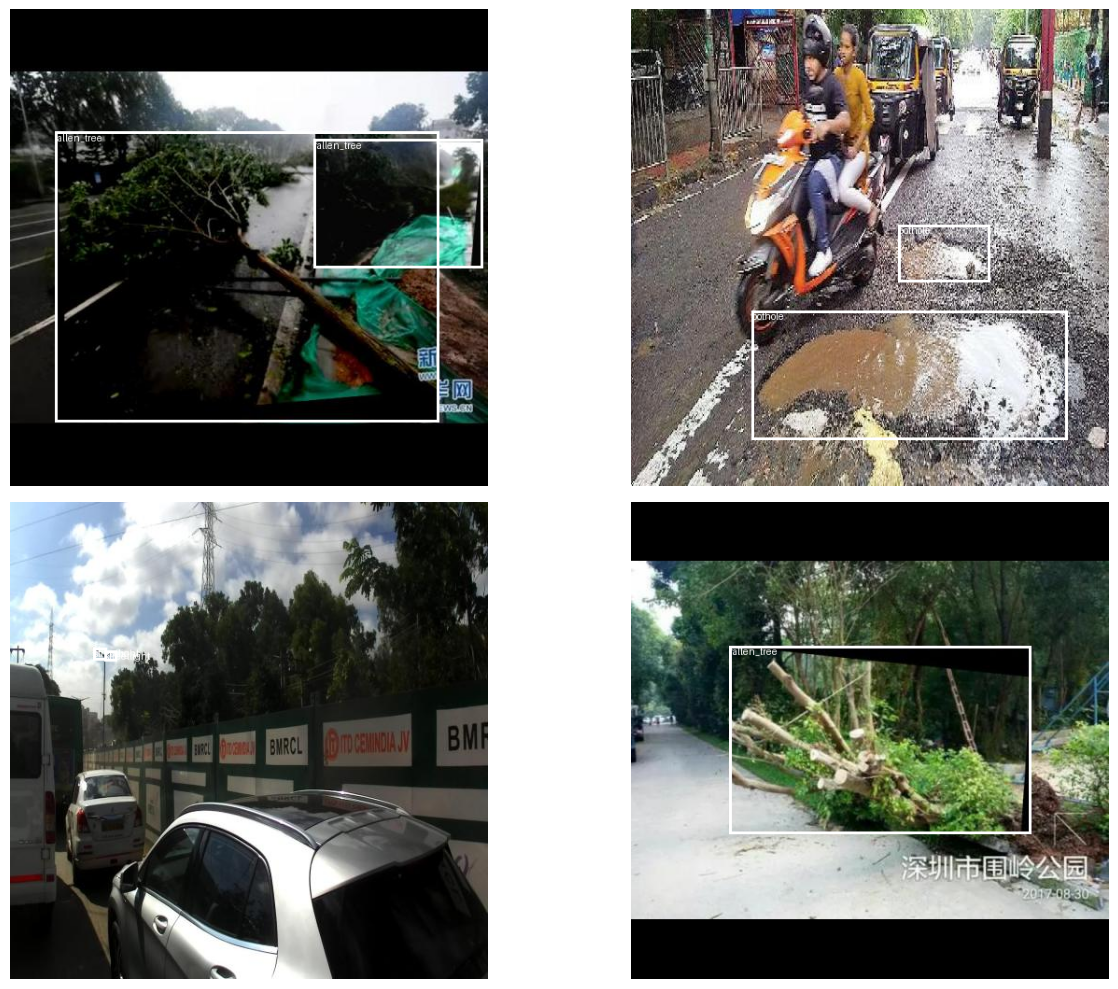

In [8]:
import random
from PIL import Image, ImageDraw
import glob
import os
import matplotlib.pyplot as plt

class_names = [
    "fallen_tree",
    "garbage",
    "pothole",
    "streetlight",
    "water_leak"
]

image_paths = glob.glob("Civic-issues-1/train/images/*")
sample_images = random.sample(image_paths, 4)

plt.figure(figsize=(14, 10))

for i, image_path in enumerate(sample_images):

    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    # Find corresponding label file
    label_path = image_path.replace("/images/", "/labels/")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    width, height = image.size

    with open(label_path, "r") as f:
        labels = f.readlines()

    for label in labels:
        values = label.strip().split()

        class_id = int(values[0])
        x_center = float(values[1]) * width
        y_center = float(values[2]) * height
        box_width = float(values[3]) * width
        box_height = float(values[4]) * height

        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2
        x2 = x_center + box_width / 2
        y2 = y_center + box_height / 2

        draw.rectangle([x1, y1, x2, y2], width=3)

        draw.text(
            (x1, y1),
            class_names[class_id]
        )

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from collections import Counter
import glob

class_counts = Counter()

label_files = glob.glob("Civic-issues-1/train/labels/*.txt")

for label_file in label_files:
    with open(label_file, "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

for class_id, count in sorted(class_counts.items()):
    print(f"{class_names[class_id]}: {count}")

fallen_tree: 4063
garbage: 473
pothole: 1256
streetlight: 2060
water_leak: 63


In [10]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [16]:
model = YOLO("yolov8n.pt")

In [17]:
results = model.train(
    data="Civic-issues-1/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    project="Nasij_runs",
    name="civic_detector"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Civic-issues-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=civic_detector-2, nbs=64, nms=False,

In [3]:
!ls /content/runs/detect/Nasij_runs/civic_detector-2/weights

ls: cannot access '/content/runs/detect/Nasij_runs/civic_detector-2/weights': No such file or directory


In [4]:
!find /content -type f -name "best.pt" 2>/dev/null

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!mkdir -p "/content/drive/MyDrive/Nasij"

In [8]:
!ls /content


drive  sample_data


In [9]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.9 MB/s eta 0:00:00


In [10]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kEq6Y7ehLTNSOHov7GuU")
project = rf.workspace("civictrackerai").project("civic-issues-6qw5e")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Civic-issues-1 in yolov8:: 100%|██████████| 10920/10920 [00:01<00:00, 6559.88it/s]


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
!ls /content/Civic-issues-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [2]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.5 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/Civic-issues-1/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/Nasij/runs",
    name="civic_detector",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Civic-issues-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=civic_detector, nbs=64, nms=

RuntimeError: Dataset '/content/Civic-issues-1/data.yaml' error ❌ '/content/Civic-issues-1/data.yaml' does not exist

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kEq6Y7ehLTNSOHov7GuU")
project = rf.workspace("civictrackerai").project("civic-issues-6qw5e")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Civic-issues-1 in yolov8:: 100%|██████████| 10920/10920 [00:01<00:00, 6301.16it/s]


In [6]:
!ls /content/Civic-issues-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [7]:
!cd /content && zip -qr "/content/drive/MyDrive/Nasij/Civic-issues-1.zip" Civic-issues-1

In [8]:
!ls -lh "/content/drive/MyDrive/Nasij/Civic-issues-1.zip"

-rw-r--r-- 1 root root 203M Aug 18 14:08 /content/drive/MyDrive/Nasij/Civic-issues-1.zip


In [9]:
!unzip -q "/content/drive/MyDrive/Nasij/Civic-issues-1.zip" -d /content

replace /content/Civic-issues-1/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/Civic-issues-1/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/Nasij/runs",
    name="civic_detector_safe",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Civic-issues-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=civic_detector_safe, nbs=64,

In [1]:
!ls -lh "/content/drive/MyDrive/Nasij/runs/civic_detector_safe/weights/"

ls: cannot access '/content/drive/MyDrive/Nasij/runs/civic_detector_safe/weights/': No such file or directory


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find "/content/drive/MyDrive/Nasij" -type f \( -name "best.pt" -o -name "last.pt" \) 2>/dev/null

/content/drive/MyDrive/Nasij/runs/civic_detector/weights/last.pt
/content/drive/MyDrive/Nasij/runs/civic_detector/weights/best.pt


In [4]:
!cp "/content/drive/MyDrive/Nasij/runs/civic_detector/weights/best.pt" \
"/content/drive/MyDrive/Nasij/best_nasij_model.pt"

In [5]:
!ls -lh "/content/drive/MyDrive/Nasij/best_nasij_model.pt"

-rw------- 1 root root 24M Aug 18 15:16 /content/drive/MyDrive/Nasij/best_nasij_model.pt


In [6]:
import os

if not os.path.exists("/content/Civic-issues-1/data.yaml"):
    print("Dataset missing — restoring from Drive...")
    !unzip -q "/content/drive/MyDrive/Nasij/Civic-issues-1.zip" -d /content
    print("Dataset restored ✅")
else:
    print("Dataset already available ✅")

Dataset missing — restoring from Drive...
unzip:  cannot find or open /content/drive/MyDrive/Nasij/Civic-issues-1.zip, /content/drive/MyDrive/Nasij/Civic-issues-1.zip.zip or /content/drive/MyDrive/Nasij/Civic-issues-1.zip.ZIP.
Dataset restored ✅


In [7]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.9 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/MyDrive/Nasij/best_nasij_model.pt"
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
test_metrics = best_model.val(
    data="/content/Civic-issues-1/data.yaml",
    split="test",
    imgsz=640,
    device=0,
    plots=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: '/content/Civic-issues-1/data.yaml' does not exist

In [10]:
!unzip -q "/content/drive/MyDrive/Nasij/Civic-issues-1.zip" -d /content

unzip:  cannot find or open /content/drive/MyDrive/Nasij/Civic-issues-1.zip, /content/drive/MyDrive/Nasij/Civic-issues-1.zip.zip or /content/drive/MyDrive/Nasij/Civic-issues-1.zip.ZIP.


In [11]:
!ls -lah "/content/drive/MyDrive/Nasij"

total 24M
-rw------- 1 root root  24M Aug 18 15:16 best_nasij_model.pt
drwx------ 3 root root 4.0K Aug 18 12:19 runs


In [12]:
!find "/content/drive/MyDrive/Nasij" -type f -iname "*.zip"

In [13]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00


In [14]:
from google.colab import userdata
from roboflow import Roboflow

rf = Roboflow(api_key=userdata.get("ROBOFLOW_API_KEY"))

project = rf.workspace("civictrackerai").project("civic-issues-6qw5e")
version = project.version(1)

dataset = version.download(
    model_format="yolov8",
    location="/content/Civic-issues-1"
)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/Civic-issues-1 in yolov8:: 100%|██████████| 10920/10920 [00:04<00:00, 2352.65it/s]


In [15]:
!ls /content/Civic-issues-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [16]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/MyDrive/Nasij/best_nasij_model.pt"
)

In [17]:
test_metrics = best_model.val(
    data="/content/Civic-issues-1/data.yaml",
    split="test",
    imgsz=640,
    device=0,
    plots=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 875.4±423.1 MB/s, size: 39.6 KB)
val: Scanning /content/Civic-issues-1/test/labels... 195 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 1.7Kit/s 0.1s
val: New cache created: /content/Civic-issues-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.2it/s 4.1s
                   all        195        503      0.612       0.59      0.555        0.3
               pothole         67        153      0.692      0.719       0.74      0.473
           streetlight        123        345      0.815       0.65      0.691       0.34
            water_leak          5          5       0.33        0.4      0.235     0.0849
Speed: 2.4ms preprocess, 4.5ms inference, 0.0ms loss, 1.5ms postprocess p

In [18]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
print("Uploaded:", image_path)

Saving pothole.jpg to pothole.jpg
Uploaded: pothole.jpg


In [19]:
prediction = best_model.predict(
    source=image_path,
    conf=0.25
)


image 1/1 /content/pothole.jpg: 480x640 1 pothole, 5.8ms
Speed: 1.8ms preprocess, 5.8ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)


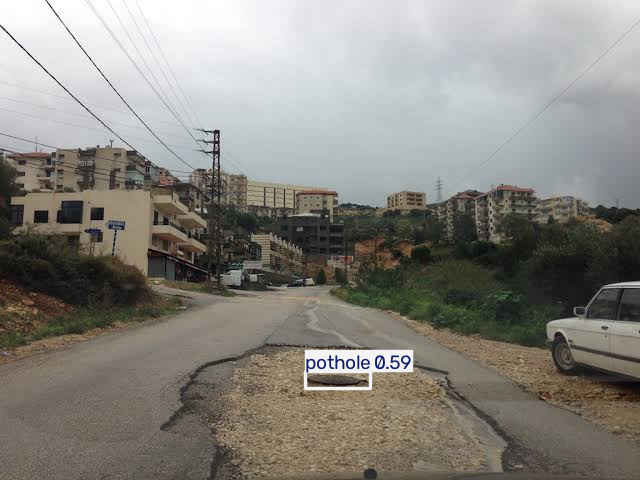

In [20]:
from PIL import Image
from IPython.display import display

annotated_image = prediction[0].plot()
annotated_image = Image.fromarray(annotated_image[..., ::-1])

display(annotated_image)

In [21]:
for box in prediction[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = best_model.names[class_id]

    print(
        f"Detected: {class_name} | "
        f"Confidence: {confidence:.2%}"
    )

Detected: pothole | Confidence: 59.08%


In [22]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
print("Uploaded:", image_path)

Saving potholes2.jpg to potholes2.jpg
Uploaded: potholes2.jpg


In [23]:
prediction = best_model.predict(
    source=image_path,
    conf=0.25
)


image 1/1 /content/potholes2.jpg: 512x640 (no detections), 41.3ms
Speed: 3.7ms preprocess, 41.3ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 640)


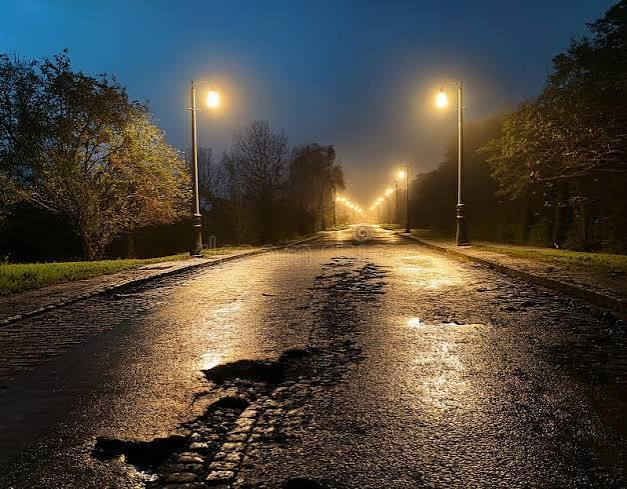

In [24]:
from PIL import Image
from IPython.display import display

annotated_image = prediction[0].plot()
annotated_image = Image.fromarray(annotated_image[..., ::-1])

display(annotated_image)

In [26]:
for box in prediction[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = best_model.names[class_id]

    print(
        f"Detected: {class_name} | "
        f"Confidence: {confidence:.2%}"
    )

In [27]:
print("Number of detections:", len(prediction[0].boxes))

Number of detections: 0
